# Lab 4: Improving and Comparing Machine Learning Models — Telco Customer Churn

**Name:** Yusra Batool

**Student ID:** 023-24-0216

**Section:** G

**GitHub Profile:** github.com/Yusra-Shah

**Kaggle Profile:** https://www.kaggle.com/yusrabatool

**Dataset:** Telco Customer Churn (Kaggle)

## Part 1 : Decision Tree Baseline Review

In [20]:
# Task 1-2 — reload data, recreate Lab 3 split, retrain chosen Decision Tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

clean_df = pd.read_csv("clean_churn.csv")
y = clean_df["Churn"].map({"No": 0, "Yes": 1})
X = clean_df.drop(columns=["Churn"])
categorical_cols = X.select_dtypes(include=["object", "str"]).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

dt_metrics = {
    "Accuracy": accuracy_score(y_test, dt_preds),
    "Precision": precision_score(y_test, dt_preds),
    "Recall": recall_score(y_test, dt_preds),
    "F1": f1_score(y_test, dt_preds),
}
print(dt_metrics)

{'Accuracy': 0.8005677785663591, 'Precision': 0.6666666666666666, 'Recall': 0.49732620320855614, 'F1': 0.5696784073506891}


**Benchmark note:** This matches the Lab 3 result exactly, using the same random_state and depth. This is the number every model in this lab has to beat.

## Part 2 : Random Forest

In [21]:
# Task 3 — train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

**Why Random Forest might generalize better:** A single unrestricted tree can memorize noise in the training data, since it keeps splitting until it perfectly separates every row. A Random Forest trains many trees on different bootstrapped samples and random feature subsets, then averages their votes, so individual trees' mistakes tend to cancel out instead of all leaning the same wrong way.

## Part 3 : Evaluation & Comparison

{'Accuracy': 0.7927608232789212, 'Precision': 0.6366666666666667, 'Recall': 0.5106951871657754, 'F1': 0.5667655786350149}


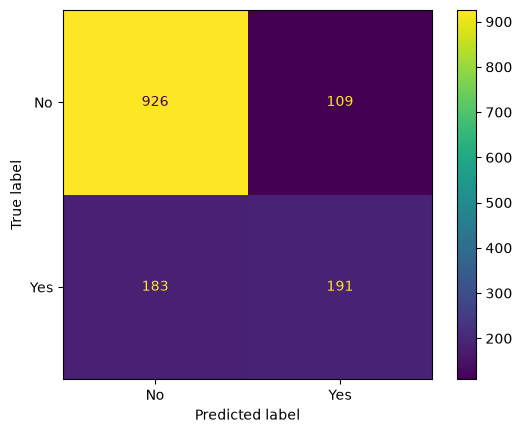

In [22]:
# Task 5 — Random Forest metrics and confusion matrix
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_preds),
    "Precision": precision_score(y_test, rf_preds),
    "Recall": recall_score(y_test, rf_preds),
    "F1": f1_score(y_test, rf_preds),
}
print(rf_metrics)

cm_rf = confusion_matrix(y_test, rf_preds)
ConfusionMatrixDisplay(cm_rf, display_labels=["No", "Yes"]).plot()

In [23]:
# Task 6 — comparison table
comparison = pd.DataFrame({
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics
})
print(comparison)

           Decision Tree  Random Forest
Accuracy        0.800568       0.792761
Precision       0.666667       0.636667
Recall          0.497326       0.510695
F1              0.569678       0.566766


**Which model is better:** The Decision Tree is actually slightly ahead on accuracy, precision, and F1, while Random Forest wins narrowly on recall (0.5107 vs 0.4973). The differences are small across the board, none exceed about 2-3 points, so this is a marginal difference, not a clear win for either model on a single split. Given Lab 2/3's finding about class imbalance, recall matters most here since it measures how many actual churners get caught, and Random Forest edges ahead on exactly that metric, even though its other scores are a touch lower.

## Part 4 : Cross-Validation

In [24]:
# Task 8 — 5-fold cross-validation, F1 score
dt_cv = cross_val_score(DecisionTreeClassifier(max_depth=6, random_state=42), X, y, cv=5, scoring="f1")
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42), X, y, cv=5, scoring="f1")

print("DT F1 scores:", dt_cv, "mean:", dt_cv.mean(), "std:", dt_cv.std())
print("RF F1 scores:", rf_cv, "mean:", rf_cv.mean(), "std:", rf_cv.std())

DT F1 scores: [0.60227273 0.53538462 0.54700855 0.58074074 0.57478006] mean: 0.5680373378115313 std: 0.024030451291583658
RF F1 scores: [0.5577812  0.5412844  0.52199413 0.56786271 0.56880734] mean: 0.551545958874841 std: 0.017785836186843828


**Cross-validation vs single split:** This actually flips the story from Part 3. Across 5 folds, the Decision Tree has a higher mean F1 (0.568) than Random Forest (0.5515), the opposite of what the single test split suggested for recall specifically. This matters because a single train/test split can be lucky or unlucky, cross-validation averages out that noise. The Random Forest's lower standard deviation (0.0178 vs 0.024) means it's more consistent fold to fold, but the Decision Tree is scoring higher on average. This makes me less confident that Random Forest is clearly better, the single-split comparison was more of a coin flip than real evidence.

## Part 5 : Hyperparameter Tuning

In [25]:
# Task 10-11 — GridSearchCV on Random Forest
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 5, 10],
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 score: 0.5679133333624713


In [26]:
# Task 12 — evaluate tuned model on test set
tuned_rf = grid.best_estimator_
tuned_preds = tuned_rf.predict(X_test)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_preds),
    "Precision": precision_score(y_test, tuned_preds),
    "Recall": recall_score(y_test, tuned_preds),
    "F1": f1_score(y_test, tuned_preds),
}
print(tuned_metrics)

{'Accuracy': 0.7970191625266146, 'Precision': 0.6506849315068494, 'Recall': 0.5080213903743316, 'F1': 0.5705705705705706}


**Tuning result:** Limiting max_depth to 10 and requiring min_samples_split=5 (instead of letting trees grow fully) nudged the Random Forest's cross-validated F1 up slightly, from 0.5515 to 0.5679, basically matching the Decision Tree's 0.568. On the test set, the tuned model's F1 (0.5706) edges out both the default Random Forest (0.5668) and the Decision Tree (0.5697), though only barely. Tuning helped, but not dramatically, this dataset doesn't have a lot of headroom left for any of these models to squeeze out.

## Part 6 : Final Comparison & Feature Importance

In [27]:
# Task 13 — final comparison table across all three models
final_comparison = pd.DataFrame({
    "Decision Tree": dt_metrics,
    "Random Forest (default)": rf_metrics,
    "Random Forest (tuned)": tuned_metrics
})
print(final_comparison)

           Decision Tree  Random Forest (default)  Random Forest (tuned)
Accuracy        0.800568                 0.792761               0.797019
Precision       0.666667                 0.636667               0.650685
Recall          0.497326                 0.510695               0.508021
F1              0.569678                 0.566766               0.570571


**Final model selection:** I'm choosing the tuned Random Forest. It has the highest F1-score of the three (0.5706), which matters most given the class imbalance, and its cross-validated score (0.5679) is close to its test score, meaning the result isn't a fluke from one lucky split. It isn't a dramatic winner, the plain Decision Tree is competitive on every metric, but the tuned Random Forest is the most balanced performer once precision, recall, and F1 are all considered together, not just accuracy.

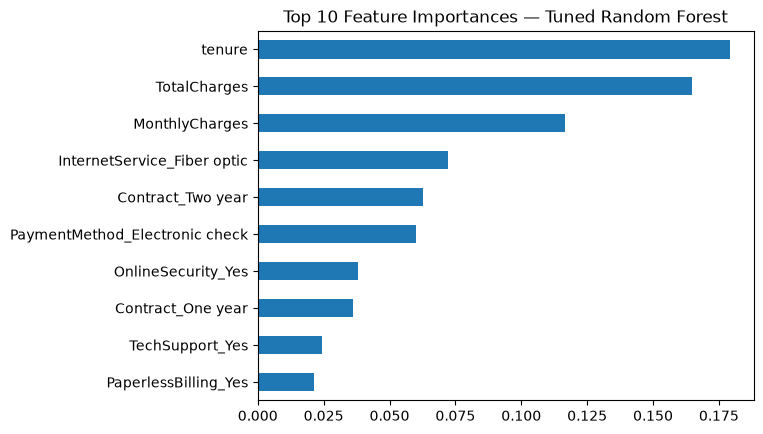

tenure                         0.179269
TotalCharges                   0.164776
MonthlyCharges                 0.116738
InternetService_Fiber optic    0.072004
Contract_Two year              0.062823
dtype: float64


In [28]:
# Task 15 — feature importance from final model
importances = pd.Series(tuned_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances — Tuned Random Forest")
plt.gca().invert_yaxis()
plt.show()
print(importances.head(5))

**Feature importance interpretation:** tenure, TotalCharges, and MonthlyCharges dominate, together making up almost half the model's decisions, matching Lab 3's Decision Tree, where tenure was also the top feature. Fiber optic internet and having a two-year contract also show up here, echoing Lab 2's EDA where fiber optic customers churned the most and long contracts churned the least. The ranking shifted a bit though, TotalCharges and MonthlyCharges matter more to the Random Forest than they did to the single Decision Tree, likely because the ensemble can use billing amounts in combination with other features instead of relying on one dominant split.

## Part 7 : Kaggle Submission & Conclusion

In [29]:
# Task 16 — Kaggle-style submission file
submission = pd.DataFrame({
    "CustomerIndex": X_test.index,
    "PredictedChurn": tuned_preds
})
submission["PredictedChurn"] = submission["PredictedChurn"].map({0: "No", 1: "Yes"})
submission.to_csv("submission.csv", index=False)
print(submission.head())

   CustomerIndex PredictedChurn
0            437             No
1           2280            Yes
2           2235             No
3           4460             No
4           3761             No


**Conclusion:** I ended up choosing the tuned Random Forest, though the margin over the Lab 3 Decision Tree is small, its F1-score (0.5706) is the highest of all three models tested, and cross-validation backs that up rather than it being a one-split fluke. Compared to the Decision Tree, the tuned Random Forest trades a slightly lower accuracy for slightly better recall, which matters more here given the churn imbalance. Its main limitation is that the improvement over a plain Decision Tree is marginal, this dataset's remaining churners seem genuinely hard to separate with the current features, not something more trees alone fixes. Cross-validation also showed the default Random Forest wasn't clearly better than the Decision Tree at all, tuning was what actually closed that gap.

**Next steps:** With more time I'd handle the class imbalance directly with class_weight="balanced" or SMOTE-based resampling, since recall is still under 0.55 for every model tried. I'd also try feature engineering, like combining tenure and Contract into a single "commitment risk" feature, since both keep showing up as top predictors separately.